La visión artificial (o visión por computador) es una rama de la inteligencia artificial que entrena a los ordenadores para extraer, procesar y comprender información útil a partir de imágenes digitales o videos. Su objetivo es emular la capacidad de la visión humana, permitiendo que las máquinas "vean", interpreten su entorno y tomen decisiones automáticas basadas en esa información.

¿Cómo funciona?
Las computadoras no ven imágenes como los humanos; ven matrices de números (valores de píxeles). Mediante algoritmos de aprendizaje profundo (Deep Learning) y redes neuronales convolucionales (CNN):

Adquiere la imagen: Captura de datos visuales mediante cámaras o sensores.

Procesa y extrae características: Identifica bordes, colores, texturas y patrones en los píxeles.

Clasifica e interpreta: Un modelo entrenado reconoce objetos, caras o eventos analizando las patrones detectados.

Principales tareas

Clasificación de imágenes: Determinar qué hay en una imagen (ej. identificar si una foto contiene un gato).

Detección de objetos: Localizar y etiquetar elementos específicos en una escena (ej. delimitar peatones y vehículos en una vía).

Segmentación: Separar píxel por píxel el objeto del fondo o definir los límites precisos de cada elemento.

Reconocimiento facial y biométrico: Identificar la identidad de una persona según sus rasgos faciales.

Aplicaciones comunes

Vehículos autónomos: Identificación de señales de tránsito, carriles y obstáculos en tiempo real.

Sector industrial y control de calidad: Inspección automatizada en líneas de ensamblaje para detectar defectos imperceptibles al ojo humano.

Medicina: Diagnóstico asistido mediante análisis de radiografías, resonancias magnéticas y tomografías.

Seguridad y vigilancia: Monitoreo y control de acceso mediante detección de movimientos o personas.

# Deteccion de rostros con python usando OpenCV
La detección de rostros con OpenCV se realiza comúnmente utilizando clasificadores en cascada de Haar (Haar Cascades), un método basado en aprendizaje automático optimizado para procesamiento en tiempo real.

In [2]:
# 1. Importar OpenCV
import cv2

# 2. Cargar y leer la imagen
imgpath = 'imagenes-caras-gratis.webp'
img = cv2.imread(imgpath)

# 3. Mostrar dimensiones y verificar OpenCV
print('Dimensiones de la imagen:', img.shape)
print('Version de OpenCV:', cv2.__version__)
print('CascadeClassifier disponible:', hasattr(cv2, 'CascadeClassifier'))


Dimensiones de la imagen: (600, 900, 3)
Version de OpenCV: 4.14.0
CascadeClassifier disponible: True


In [3]:
# 6. Convertir la imagen a escala de grises
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Mostrar ventana (presiona cualquier tecla en la ventana para cerrarla)
cv2.imshow('Imagen en escala de grises', gray_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [4]:
#7. Cargar el clasificador de rostros
cascade = "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(cascade)

#8. Verificar si el clasificador se cargó correctamente
if face_cascade.empty():
    print("Error al cargar el clasificador de rostros.")
else:
    print("Clasificador de rostros cargado correctamente.")

Clasificador de rostros cargado correctamente.


In [5]:
# 9. Se realiza la deteccion del rostro en la imagen en escala de grises. para ellos se hace uso de la funcion detectMultiScale()
# esta se utiliza para detectar caras de diferentes tamaños en la imagen de entrada

face= face_cascade.detectMultiScale(gray_img, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))

In [6]:
# 10. For para recprrer tpdas ñas caras y dibujar un rectangulo sobre la imagen original

for (x, y, w, h) in face:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)

# 11. la imagenes se cargan en BGR, se debe convertir a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

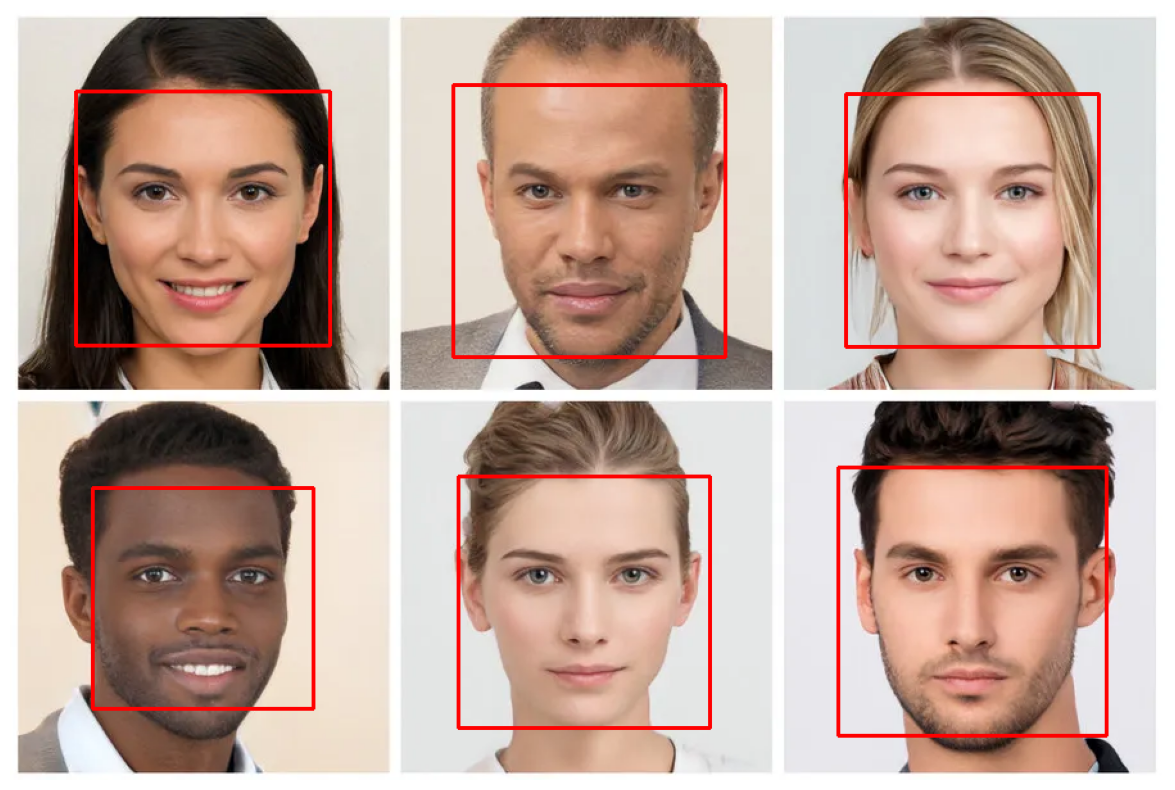

In [7]:
#12. importar matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plt.imshow(img_rgb)
plt.axis('off')

# Captura de video en tiempo real

In [8]:
#1. Acceder a la camara de nuestro pc y leer un flujo de datos en tiempo real
video_capture = cv2.VideoCapture(0)

#2. Funcion para detectar el rostro con flujo de video y dibujar un recuadro delimitador

def detect_bounding_box(vid):
    gray_img = cv2.cvtColor(vid, cv2.COLOR_BGR2GRAY)
    face = face_cascade.detectMultiScale(gray_img, 1.1, 5, minSize=(40, 40))
    for (x, y, w, h) in face:
        cv2.rectangle(vid, (x, y), (x + w, y + h), (255, 0, 0), 2)
    return face

In [9]:
# 3. Bucle while para detectar caras en tiempo real
while True:
    result, video_frame = video_capture.read()
    if result is False:
        break
    faces = detect_bounding_box(video_frame)

    cv2.imshow('Mi cara detectada - Presiona Q para salir', video_frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Liberar camara y ventanas fuera del bucle
video_capture.release()
cv2.destroyAllWindows()


KeyboardInterrupt: 